# Monte Carlo Sensitivity Analysis


## Setup and Data Load

Monte Carlo simulations randomize weights across the implemented score variables only. The raw source file contains additional reserved columns that are not used in the Version 1 sensitivity analysis.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

states = pd.read_csv("../sources/state_competitiveness.csv")
output_dir = Path("../outputs/tables")
output_dir.mkdir(parents=True, exist_ok=True)


## Score Construction

The sensitivity analysis uses the same implemented score variables as the regional competitiveness model. `btm_score` is retained as a documented score field when available, but it is not included in the Version 1 Monte Carlo weight draws unless populated with implemented source data.


In [2]:
states["price_score"] = (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"]
) / (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"].min()
)

states["capacity_score"] = (
    states["Grid_Capacity_MW"]
    - states["Grid_Capacity_MW"].min()
) / (
    states["Grid_Capacity_MW"].max()
    - states["Grid_Capacity_MW"].min()
)

states["renewable_score"] = (
    states["Renewable_Share_Percent"]
    - states["Renewable_Share_Percent"].min()
) / (
    states["Renewable_Share_Percent"].max()
    - states["Renewable_Share_Percent"].min()
)

data_center_counts = {
    "Virginia": 609,
    "Texas": 467,
    "California": 287,
    "Georgia": 219,
    "Ohio": 210,
    "Arizona": 156,
    "Washington": 103,
    "North Carolina": 93,
    "Oregon": 125,
    "Nevada": 71,
    "Utah": 43,
    "Pennsylvania": 131,
    "Illinois": 228,
    "Indiana": 122,
    "Tennessee": 61,
}

states["data_center_count"] = states["State"].map(data_center_counts)
states["ecosystem_score"] = (
    states["data_center_count"] - states["data_center_count"].min()
) / (
    states["data_center_count"].max()
    - states["data_center_count"].min()
)

if (
    "Behind_The_Meter_Potential_Score" in states.columns
    and states["Behind_The_Meter_Potential_Score"].notna().any()
):
    states["btm_score"] = (
        states["Behind_The_Meter_Potential_Score"]
        - states["Behind_The_Meter_Potential_Score"].min()
    ) / (
        states["Behind_The_Meter_Potential_Score"].max()
        - states["Behind_The_Meter_Potential_Score"].min()
    )
else:
    states["btm_score"] = np.nan

states["interconnection_score"] = states["Interconnection_Friction_Score"]

states["competitiveness_score"] = (
    0.25 * states["price_score"]
    + 0.25 * states["capacity_score"]
    + 0.20 * states["renewable_score"]
    + 0.20 * states["ecosystem_score"]
    + 0.10 * states["interconnection_score"]
)

score_preview_columns = [
    "State",
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "btm_score",
    "interconnection_score",
    "competitiveness_score",
]

states[score_preview_columns].head()


,State,price_score,capacity_score,renewable_score,ecosystem_score,btm_score,interconnection_score,competitiveness_score
0,Texas,1.000000,1.000000,0.280353,0.749117,NaN,1.00,0.805894
1,Virginia,0.951884,0.119400,0.099338,1.000000,NaN,0.55,0.542689
2,Arizona,0.828986,0.143002,0.112583,0.199647,NaN,0.75,0.380443
3,California,0.000000,0.547304,0.706402,0.431095,NaN,0.20,0.384326
4,Nevada,0.902609,0.040800,0.448124,0.049470,NaN,0.75,0.410371


## Shared Monte Carlo Simulation Table

This notebook runs a sensitivity analysis over model weights using a Dirichlet distribution. All Monte Carlo outputs are generated from one shared simulation table so winner frequency, top-3 frequency, and score distributions are directly comparable.


In [3]:
score_columns = [
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "interconnection_score",
]

states[score_columns].describe()


,price_score,capacity_score,renewable_score,ecosystem_score,interconnection_score
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,0.855614,0.210402,0.274761,0.268551,0.630000
std,0.241981,0.253215,0.331380,0.278107,0.181068
min,0.000000,0.000000,0.000000,0.000000,0.200000
25%,0.875942,0.088231,0.083885,0.097173,0.525000
50%,0.907826,0.130967,0.099338,0.155477,0.650000
75%,0.943768,0.207134,0.364238,0.318905,0.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
n_simulations = 10_000
np.random.seed(42)

records = []

for i in range(n_simulations):
    weights = np.random.dirichlet(np.ones(len(score_columns)))
    simulation_scores = states[score_columns].values @ weights

    temp = states[["State"]].copy()
    temp["score"] = simulation_scores
    temp["rank"] = temp["score"].rank(
        ascending=False,
        method="first",
    ).astype(int)

    for _, row in temp.iterrows():
        records.append({
            "simulation": i,
            "State": row["State"],
            "score": row["score"],
            "rank": row["rank"],
            **{
                f"weight_{col}": weight
                for col, weight in zip(score_columns, weights)
            },
        })

monte_carlo_results = pd.DataFrame(records)

monte_carlo_results.head()


,simulation,State,score,rank,weight_price_score,weight_capacity_score,weight_renewable_score,weight_ecosystem_score,weight_interconnection_score
0,0,Texas,0.799848,1,0.079825,0.512038,0.223986,0.155297,0.028854
1,0,Virginia,0.330538,5,0.079825,0.512038,0.223986,0.155297,0.028854
2,0,Arizona,0.217258,10,0.079825,0.512038,0.223986,0.155297,0.028854
3,0,California,0.511183,2,0.079825,0.512038,0.223986,0.155297,0.028854
4,0,Nevada,0.222638,9,0.079825,0.512038,0.223986,0.155297,0.028854


In [5]:
winner_frequency = (
    monte_carlo_results.loc[monte_carlo_results["rank"] == 1]
    .groupby("State")
    .size()
    .reindex(states["State"], fill_value=0)
    .div(n_simulations)
    .mul(100)
    .rename("Winner_Frequency_Percent")
    .reset_index()
)

top3_frequency = (
    monte_carlo_results.loc[monte_carlo_results["rank"] <= 3]
    .groupby("State")
    .size()
    .reindex(states["State"], fill_value=0)
    .div(n_simulations)
    .mul(100)
    .rename("Top_3_Frequency_Percent")
    .reset_index()
)

score_summary = (
    monte_carlo_results
    .groupby("State")["score"]
    .agg(
        median_score="median",
        mean_score="mean",
        std_score="std",
    )
    .reset_index()
)

monte_carlo_summary = (
    score_summary
    .merge(winner_frequency, on="State", how="left")
    .merge(top3_frequency, on="State", how="left")
    .sort_values("median_score", ascending=False)
)

monte_carlo_summary


,State,median_score,mean_score,std_score,Winner_Frequency_Percent,Top_3_Frequency_Percent
11,Texas,0.823383,0.804840,0.114483,78.43,96.97
14,Washington,0.601544,0.594265,0.161461,17.44,80.96
8,Oregon,0.562239,0.554196,0.153789,0.00,46.54
13,Virginia,0.547127,0.546754,0.159408,4.13,44.53
5,Nevada,0.438458,0.438682,0.142932,0.00,0.21
3,Illinois,0.426218,0.431410,0.115367,0.00,8.71
0,Arizona,0.399016,0.407054,0.127782,0.00,0.53
2,Georgia,0.386542,0.398397,0.118608,0.00,0.45
7,Ohio,0.381587,0.389277,0.134482,0.00,0.01
1,California,0.379437,0.376511,0.102351,0.00,20.31


In [6]:
robustness_ranking = monte_carlo_summary.copy()

robustness_ranking["robustness_score"] = (
    robustness_ranking["median_score"]
    / robustness_ranking["std_score"]
)

robustness_ranking = (
    robustness_ranking
    .sort_values("robustness_score", ascending=False)
)

robustness_ranking[
    [
        "State",
        "median_score",
        "std_score",
        "robustness_score",
        "Winner_Frequency_Percent",
        "Top_3_Frequency_Percent",
    ]
]


,State,median_score,std_score,robustness_score,Winner_Frequency_Percent,Top_3_Frequency_Percent
11,Texas,0.823383,0.114483,7.192193,78.43,96.97
14,Washington,0.601544,0.161461,3.725633,17.44,80.96
1,California,0.379437,0.102351,3.707222,0.00,20.31
3,Illinois,0.426218,0.115367,3.694446,0.00,8.71
8,Oregon,0.562239,0.153789,3.655910,0.00,46.54
13,Virginia,0.547127,0.159408,3.432235,4.13,44.53
2,Georgia,0.386542,0.118608,3.258982,0.00,0.45
0,Arizona,0.399016,0.127782,3.122630,0.00,0.53
5,Nevada,0.438458,0.142932,3.067600,0.00,0.21
9,Pennsylvania,0.350118,0.123155,2.842910,0.00,0.15


## Export Monte Carlo Outputs


In [7]:
monte_carlo_results.to_csv(
    output_dir / "monte_carlo_results.csv",
    index=False,
)
monte_carlo_summary.to_csv(
    output_dir / "monte_carlo_summary.csv",
    index=False,
)
winner_frequency.to_csv(
    output_dir / "monte_carlo_winner_frequency.csv",
    index=False,
)
top3_frequency.to_csv(
    output_dir / "monte_carlo_top3_frequency.csv",
    index=False,
)
robustness_ranking.to_csv(
    output_dir / "monte_carlo_robustness_ranking.csv",
    index=False,
)


## Winner Frequency


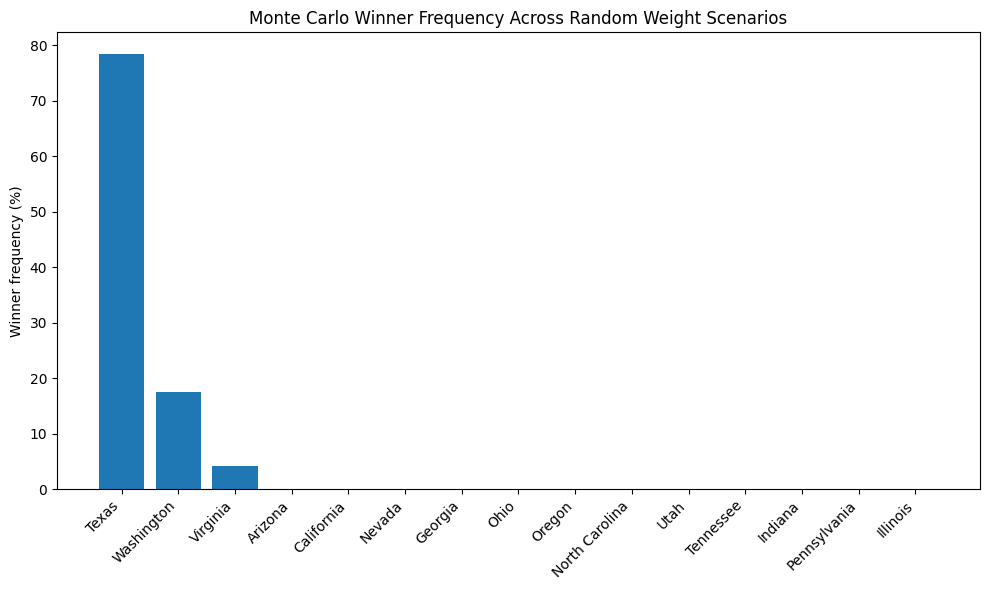

In [8]:
winner_plot = winner_frequency.sort_values(
    "Winner_Frequency_Percent",
    ascending=False,
)

plt.figure(figsize=(10, 6))
plt.bar(
    winner_plot["State"],
    winner_plot["Winner_Frequency_Percent"],
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Winner frequency (%)")
plt.title("Monte Carlo Winner Frequency Across Random Weight Scenarios")
plt.tight_layout()
plt.show()


## Top-3 Frequency


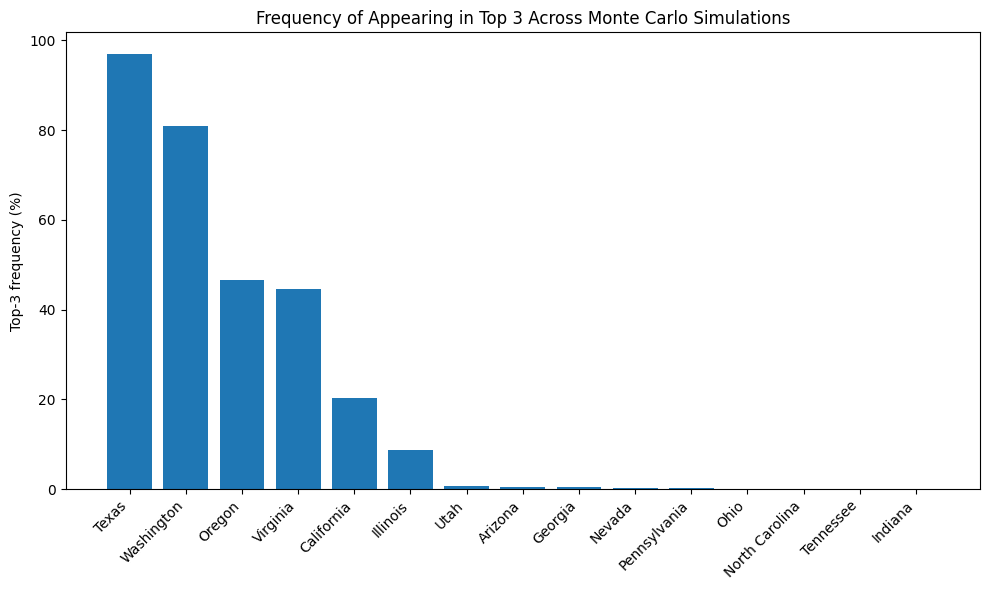

In [9]:
top3_plot = top3_frequency.sort_values(
    "Top_3_Frequency_Percent",
    ascending=False,
)

plt.figure(figsize=(10, 6))
plt.bar(
    top3_plot["State"],
    top3_plot["Top_3_Frequency_Percent"],
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Top-3 frequency (%)")
plt.title("Frequency of Appearing in Top 3 Across Monte Carlo Simulations")
plt.tight_layout()
plt.show()


## Score Distribution


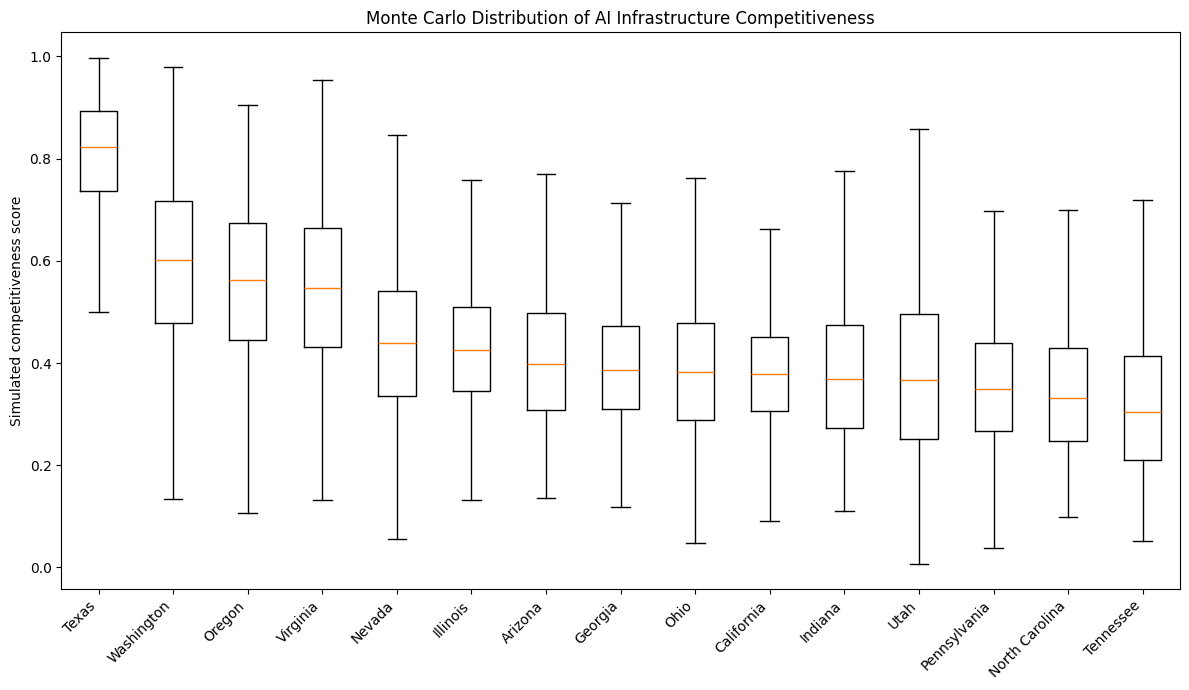

In [10]:
state_order = monte_carlo_summary["State"]

data_to_plot = [
    monte_carlo_results.loc[
        monte_carlo_results["State"] == state,
        "score",
    ]
    for state in state_order
]

plt.figure(figsize=(12, 7))
plt.boxplot(
    data_to_plot,
    tick_labels=state_order,
    showfliers=False,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Simulated competitiveness score")
plt.title("Monte Carlo Distribution of AI Infrastructure Competitiveness")
plt.tight_layout()
plt.show()


## Strength vs Robustness


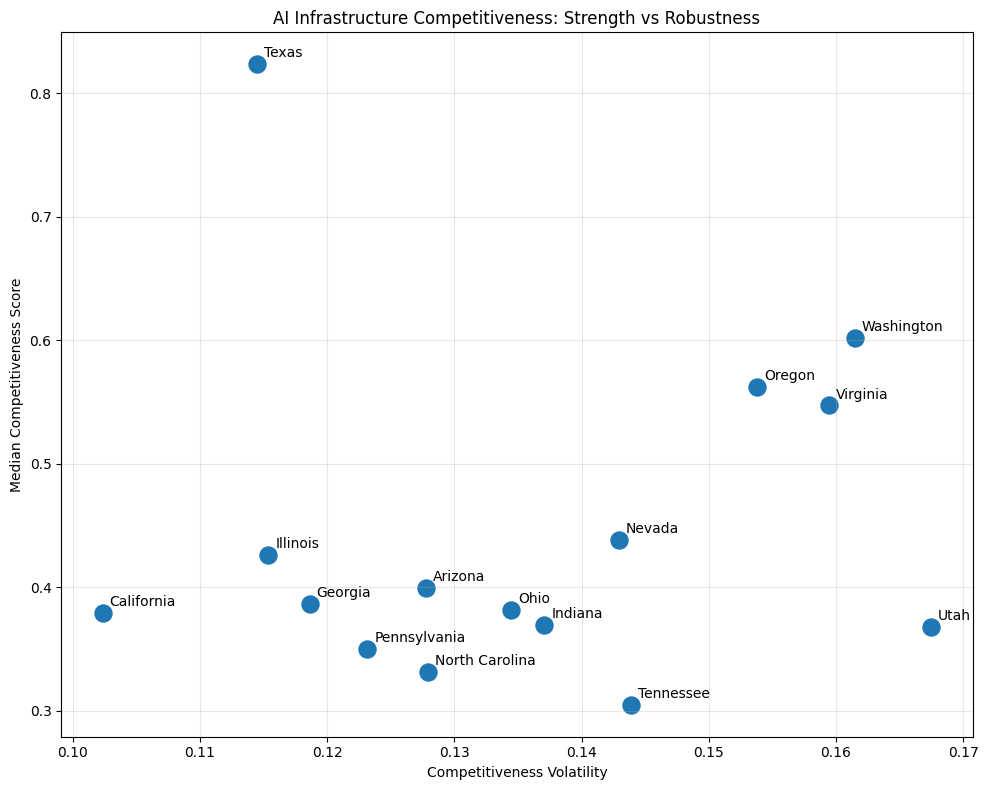

In [11]:
plt.figure(figsize=(10, 8))
plt.scatter(
    monte_carlo_summary["std_score"],
    monte_carlo_summary["median_score"],
    s=150,
)

for _, row in monte_carlo_summary.iterrows():
    plt.annotate(
        row["State"],
        (
            row["std_score"],
            row["median_score"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Competitiveness Volatility")
plt.ylabel("Median Competitiveness Score")
plt.title("AI Infrastructure Competitiveness: Strength vs Robustness")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
